# Titanic Survival Prediction Exploratory Data Analysis (EDA)

This notebook performs exploratory data analysis for the Kaggle Titanic dataset. The goal is to understand the data distribution, missing values, feature relationships before training.


## 1. Imports and reproducibility

In [28]:
import sys
print(sys.executable)

/Users/shani/University/titanic_pytorch_streamlit/.venv/bin/python


In [3]:
import shutil
from pathlib import Path

import kagglehub
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

SEED = 42
DATA_DIR = Path("data")
COMPETITION_NAME = "titanic"
sns.set_theme(style="whitegrid")


## 2. Download data directly from Kaggle

The code uses `kagglehub` to download the Titanic competition files directly from Kaggle. Please create a Legacy API Key (as described in README file) before running this notebook.


In [27]:
def download_titanic_data(data_dir=DATA_DIR):
    # Create the data directory if it does not already exist
    data_dir.mkdir(parents=True, exist_ok=True)
    train_csv = data_dir / "train.csv"
    test_csv = data_dir / "test.csv"

    # Skip download if the main dataset files already exist
    if train_csv.exists() and test_csv.exists():
        print("Titanic data already exists.")
        return
    # Download the Titanic competition files from Kaggle
    downloaded_path = Path(kagglehub.competition_download(COMPETITION_NAME))
    # Copy the required files into the local data directory
    for file_name in ["train.csv", "test.csv", "gender_submission.csv"]:
        source = downloaded_path / file_name
        destination = data_dir / file_name
        if source.exists():
            shutil.copy2(source, destination)

    # Validate that the expected files were downloaded successfully
    if not train_csv.exists():
        raise FileNotFoundError("Expected data/train.csv after Kaggle download, but it was not found.")
    if not test_csv.exists():
        raise FileNotFoundError("Expected data/test.csv after Kaggle download, but it was not found.")

    print(f"Titanic data saved to: {data_dir.resolve()}")

download_titanic_data()


Titanic data already exists.


## 3. Load and inspect the data

In [5]:
train_df = pd.read_csv(DATA_DIR / "train.csv")
test_df = pd.read_csv(DATA_DIR / "test.csv")

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)
train_df.head()

Train shape: (891, 12)
Test shape: (418, 11)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [7]:
test_df.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [6]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


## 4. Survival distribution

Survived
0    549
1    342
Name: count, dtype: int64
Survival rate: 0.384


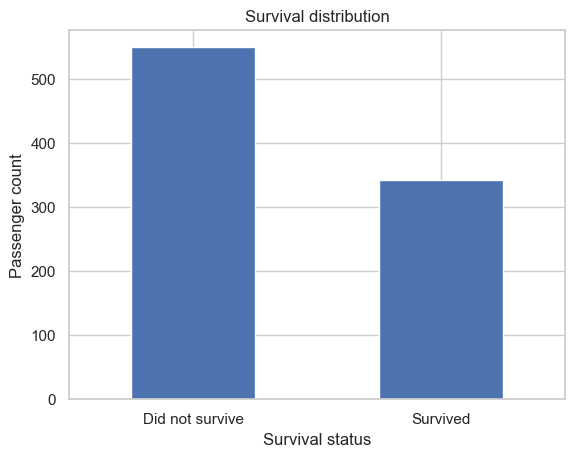

In [12]:
survival_counts = train_df["Survived"].value_counts().sort_index() # Count how many passengers belong to each class
survival_rate = train_df["Survived"].mean() # Calculate the overall survival rate (Survived is binary so the mean equals the proportion of passengers who survived)

print(survival_counts)
print(f"Survival rate: {survival_rate:.3f}")

ax = survival_counts.plot(kind="bar") # Plot the survival distribution as a bar chart
ax.set_xticklabels(["Did not survive", "Survived"], rotation=0)
ax.set_title("Survival distribution")
ax.set_xlabel("Survival status")
ax.set_ylabel("Passenger count")
plt.show()

## 5. Missing values

This helps decide which features require imputation before model training.


In [ ]:
missing = train_df.isna().mean().sort_values(ascending=False) # Calculate the missing value ratio for each column
missing[missing > 0] # Display columns that contain missing values

Cabin       0.771044
Age         0.198653
Embarked    0.002245
dtype: float64

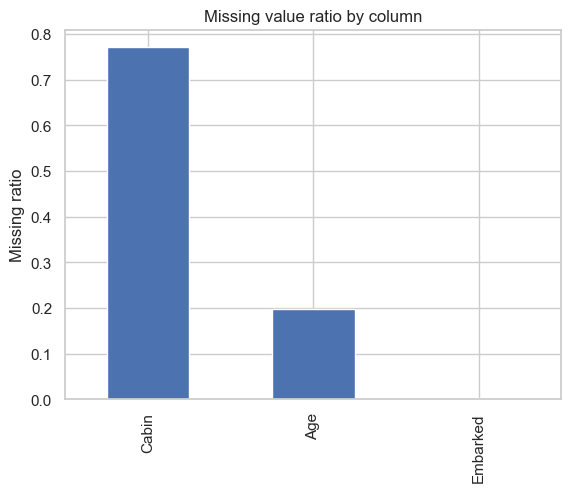

In [ ]:
ax = missing[missing > 0].plot(kind="bar") # Plot the missing value ratios as a bar chart
ax.set_title("Missing value ratio by column")
ax.set_ylabel("Missing ratio")
plt.show()

## 6. Survival by categorical features

,count,mean
Sex,,
female,314,0.742038
male,577,0.188908


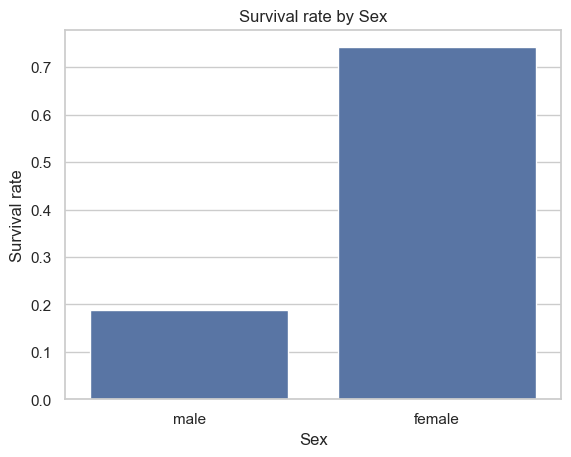

,count,mean
Pclass,,
1,216,0.629630
2,184,0.472826
3,491,0.242363


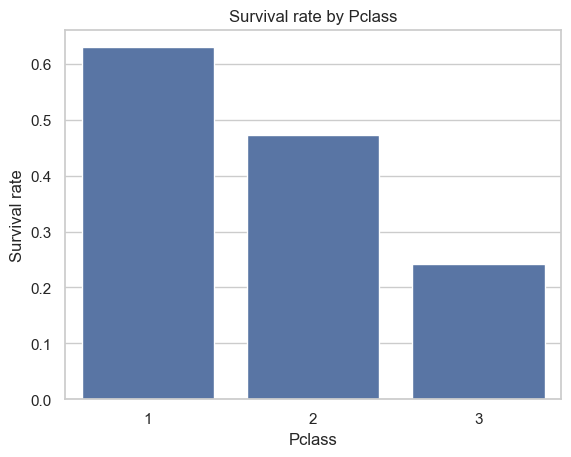

,count,mean
Embarked,,
C,168,0.553571
Q,77,0.389610
S,644,0.336957


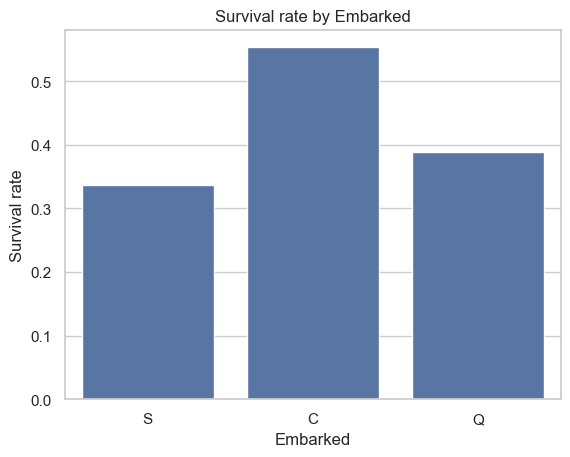

In [14]:
categorical_columns = ["Sex", "Pclass", "Embarked"] # Select categorical features to analyze

for col in categorical_columns: # Analyze the survival rate for each category in each categorical feature
    display(train_df.groupby(col)["Survived"].agg(["count", "mean"]).sort_values("mean", ascending=False)) # count = total number of passengers in each category, mean = survival rate of each category
    ax = sns.barplot(data=train_df, x=col, y="Survived", errorbar=None)
    ax.set_title(f"Survival rate by {col}")
    ax.set_ylabel("Survival rate")
    plt.show()

## 7. Survival by numeric features

In [19]:
numeric_columns = ["Age", "Fare", "SibSp", "Parch"] # Select numeric features for summary statistics
train_df[numeric_columns + ["Survived"]].describe() # Display descriptive statistics for numeric features, including survival status

,Age,Fare,SibSp,Parch,Survived
count,714.000000,891.000000,891.000000,891.000000,891.000000
mean,29.699118,32.204208,0.523008,0.381594,0.383838
std,14.526497,49.693429,1.102743,0.806057,0.486592
min,0.420000,0.000000,0.000000,0.000000,0.000000
25%,20.125000,7.910400,0.000000,0.000000,0.000000
50%,28.000000,14.454200,0.000000,0.000000,0.000000
75%,38.000000,31.000000,1.000000,0.000000,1.000000
max,80.000000,512.329200,8.000000,6.000000,1.000000


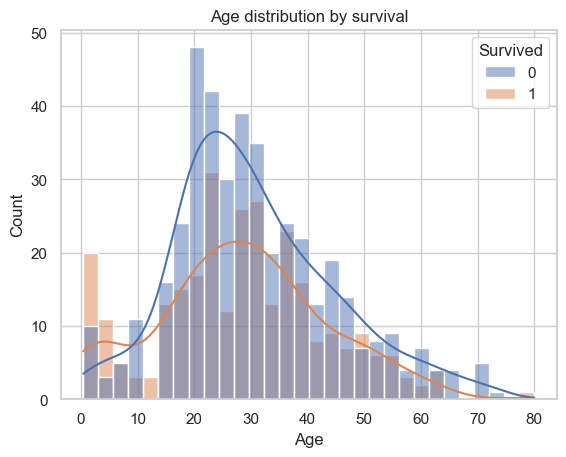

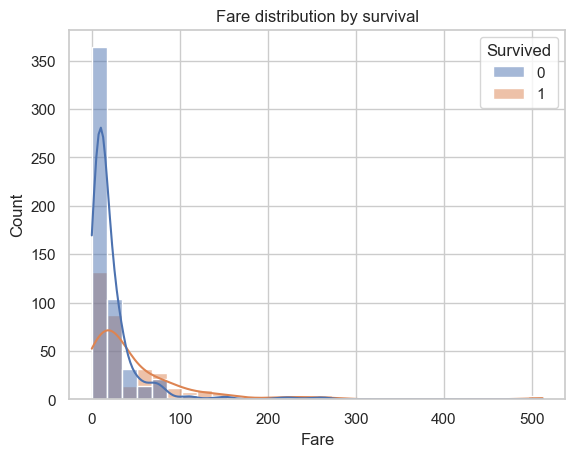

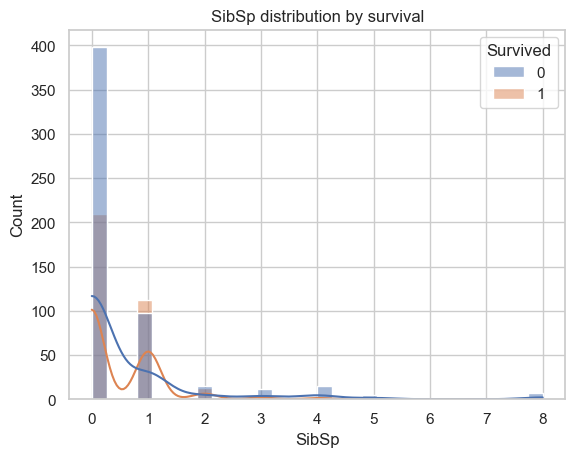

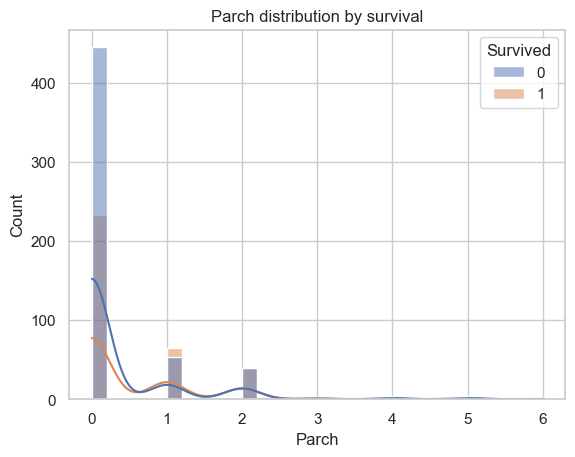

In [20]:
for col in numeric_columns: # Plot the distributions of selected numeric features by survival outcome
    ax = sns.histplot(data=train_df, x=col, hue="Survived", kde=True, bins=30)
    ax.set_title(f"{col} distribution by survival")
    plt.show()

## 8. Exploring new features

This section explores new features created from the original Titanic columns. The goal is to check whether these features are useful for predicting survival and should be included later in the training pipeline.

In [24]:
def extract_title(name): # Extract passenger title from the Name column
    if pd.isna(name) or "," not in name or "." not in name:
        return "Unknown"
    title = name.split(",", 1)[1].split(".", 1)[0].strip()
    return title if title in {"Mr", "Mrs", "Miss", "Master"} else "Rare"

# Create new features for EDA
eda_df = train_df.copy()
eda_df["Title"] = eda_df["Name"].apply(extract_title)
eda_df["FamilySize"] = eda_df["SibSp"] + eda_df["Parch"] + 1
eda_df["IsAlone"] = (eda_df["FamilySize"] == 1).astype(int)
eda_df["CabinKnown"] = eda_df["Cabin"].notna().astype(int)
eda_df["TicketGroupSize"] = eda_df.groupby("Ticket")["Ticket"].transform("count")

eda_df[["Title", "FamilySize", "IsAlone", "CabinKnown", "TicketGroupSize", "Survived"]].head()

,Title,FamilySize,IsAlone,CabinKnown,TicketGroupSize,Survived
0,Mr,2,0,0,1,0
1,Mrs,2,0,1,1,1
2,Miss,1,1,0,1,1
3,Mrs,2,0,1,2,1
4,Mr,1,1,0,1,0


,count,mean
Title,,
Mrs,125,0.792000
Miss,182,0.697802
Master,40,0.575000
Rare,27,0.444444
Mr,517,0.156673


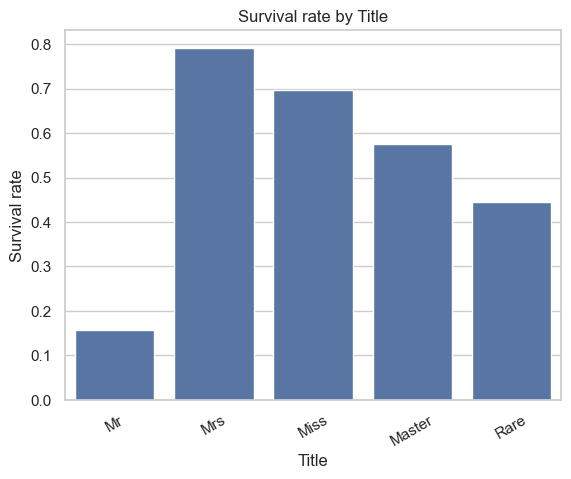

,count,mean
IsAlone,,
0,354,0.505650
1,537,0.303538


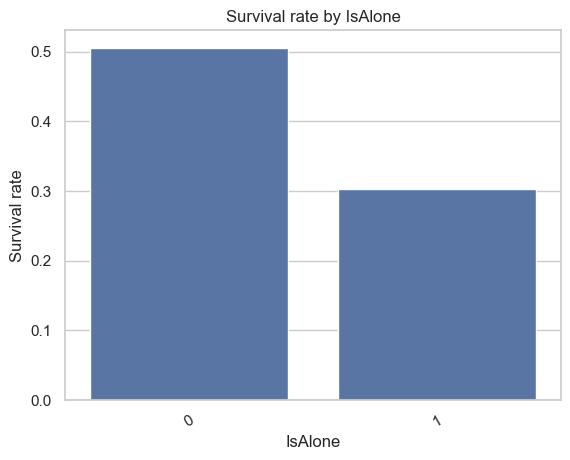

,count,mean
CabinKnown,,
1,204,0.666667
0,687,0.299854


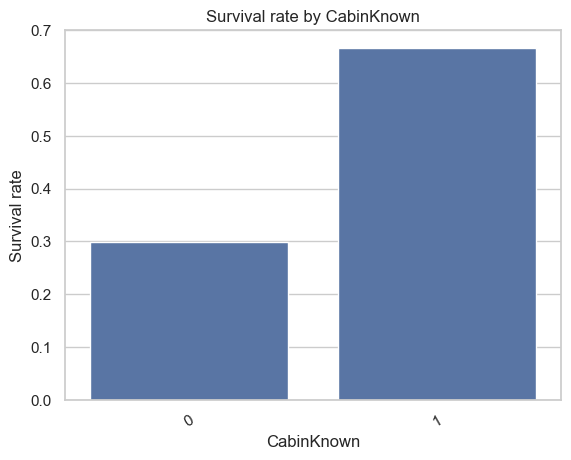

In [25]:
for col in ["Title", "IsAlone", "CabinKnown"]: # Check survival patterns for selected new features
    display(eda_df.groupby(col)["Survived"].agg(["count", "mean"]).sort_values("mean", ascending=False)) # Show passenger count and survival rate for each category
    ax = sns.barplot(data=eda_df, x=col, y="Survived", errorbar=None)
    ax.set_title(f"Survival rate by {col}")
    ax.set_ylabel("Survival rate")
    plt.xticks(rotation=30)
    plt.show()

## 9. Correlation check

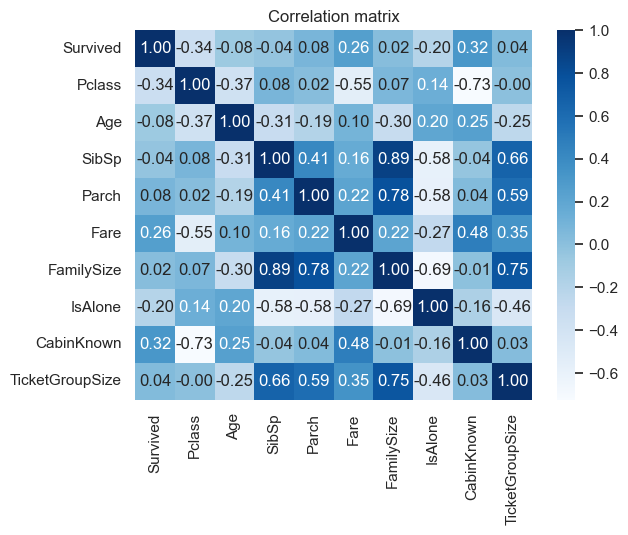

In [26]:
corr_cols = ["Survived", "Pclass", "Age", "SibSp", "Parch", "Fare", "FamilySize", "IsAlone", "CabinKnown", "TicketGroupSize"] # Select numeric columns for correlation analysis
ax = sns.heatmap(eda_df[corr_cols].corr(), annot=True, fmt=".2f", cmap="Blues") # Plot a correlation matrix to examine relationships between numeric features
ax.set_title("Correlation matrix")
plt.show()